# Data Processing with NeuroKit2

In this section, we use the `neurokit2` library for analyzing and preparing bio-signals (ECG, GSR, EEG and RESPIRATORY) before building a machine learning model.
`neurokit2` provides functionalities such as:

- Extracting features from signals.
- Filtering and denoising.
- Segmenting signals and detecting critical points, such as R-wave peaks in ECG.
- Visualizing bio-signals for better insights into the data.
- This step is essential for data preparation as it ensures that our models are both accurate and robust.

In [1]:
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import gc

## Loading the Data

We are using a dataset with real physiological data collected from eighteen pilots. This dataset was downloaded earlier from the Kaggle competition: [Reducing Commercial Aviation Fatalities](https://www.kaggle.com/c/reducing-commercial-aviation-fatalities/data).  

The dataset contains multiple physiological signals (ECG, GSR, EEG and RESPIRATORY) recorded during simulated flight conditions.

In [3]:
df = pd.read_csv('../data/train.csv')

In [21]:
eeg_columns = ['eeg_fp1', 'eeg_f7', 'eeg_f8', 'eeg_t4', 'eeg_t6', 'eeg_t5', 'eeg_t3', 'eeg_fp2', 
               'eeg_o1', 'eeg_p3', 'eeg_pz', 'eeg_f3', 'eeg_fz', 'eeg_f4', 'eeg_c4', 'eeg_p4', 
               'eeg_poz', 'eeg_c3', 'eeg_cz', 'eeg_o2']

eeg_signals = df[eeg_columns]
respiratory_signal = df['r']
ecg_signal = df['ecg']
gsr_signal = df['gsr']

## Signal Processing and Visualization

In this section, we process and visualize respiratory, ECG and GSR signals using `neurokit2`. After processing each signal, we clean up memory by deleting large variables and invoking the garbage collector to ensure efficient memory management.

In [40]:
filtered_eeg_signals = nk.signal_filter(eeg_signals['eeg_fp1'], lowcut=0.9, highcut=10, sampling_rate=256)

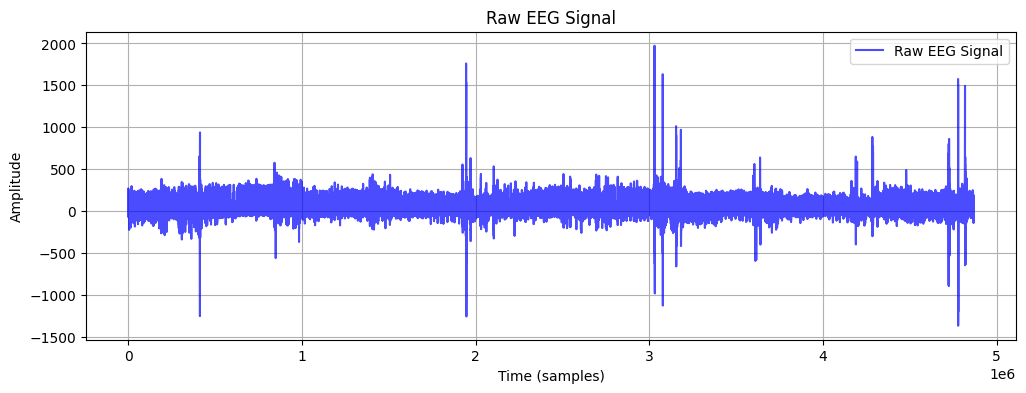

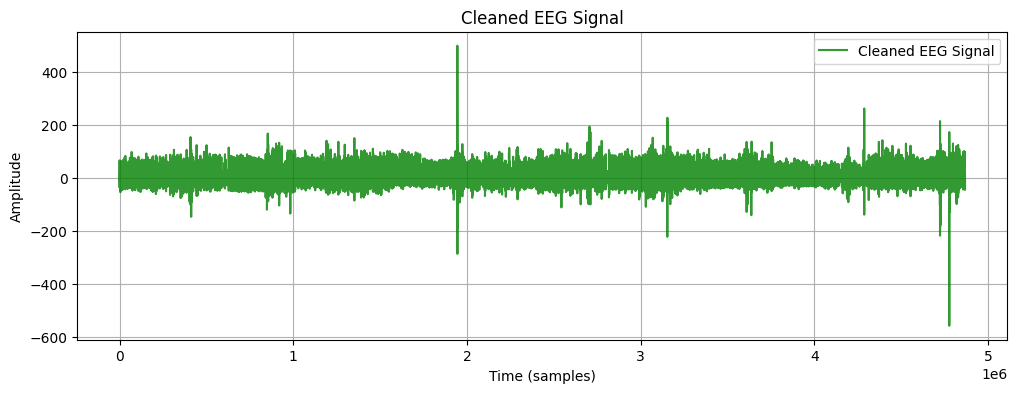

In [41]:
# Plot raw respiratory signal
plt.figure(figsize=(12, 4))
plt.plot(eeg_signals['eeg_fp1'], label="Raw EEG Signal", color="blue", alpha=0.7)
plt.title("Raw EEG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Plot cleaned respiratory signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_eeg_signals, label="Cleaned EEG Signal", color="green", alpha=0.8)
plt.title("Cleaned EEG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# del filtered_eeg_signals
# del eeg_signals
# gc.collect()

In [25]:
filtered_respiratory_signal, info_rsp = nk.rsp_process(respiratory_signal, sampling_rate=256)

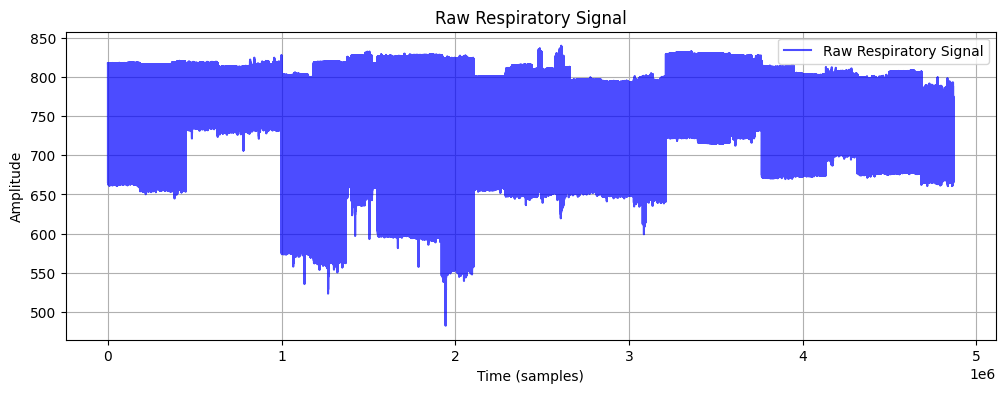

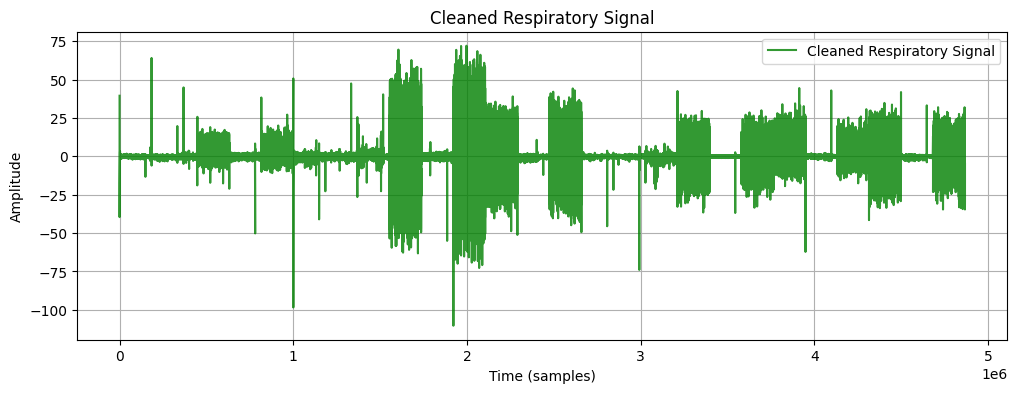

3458

In [26]:
# Plot raw respiratory signal
plt.figure(figsize=(12, 4))
plt.plot(respiratory_signal, label="Raw Respiratory Signal", color="blue", alpha=0.7)
plt.title("Raw Respiratory Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Plot cleaned respiratory signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_respiratory_signal["RSP_Clean"], label="Cleaned Respiratory Signal", color="green", alpha=0.8)
plt.title("Cleaned Respiratory Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

del filtered_respiratory_signal
del respiratory_signal
gc.collect()

In [17]:
filtered_ecg_signal, info_ecg = nk.ecg_process(ecg_signal, sampling_rate=256)

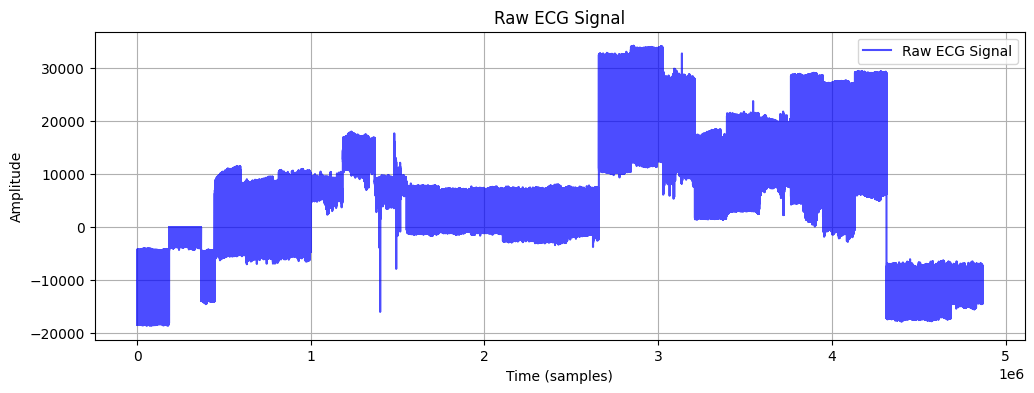

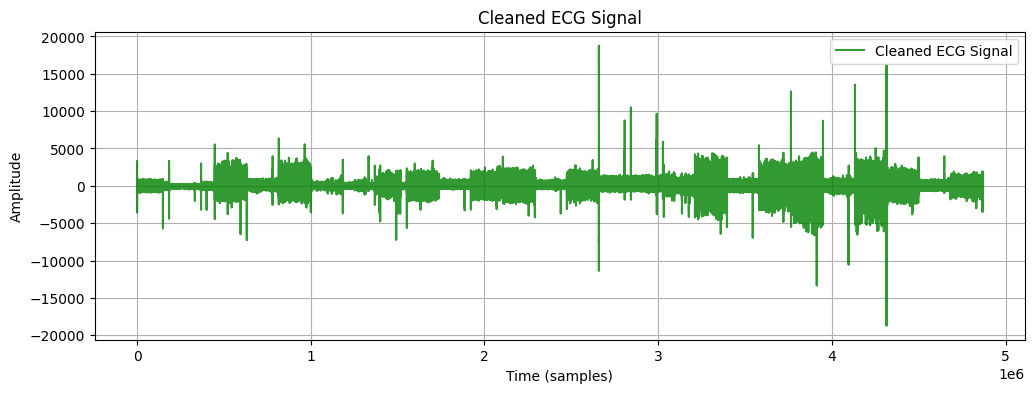

3565

In [18]:
# Plot raw ECG signal
plt.figure(figsize=(12, 4))
plt.plot(ecg_signal, label="Raw ECG Signal", color="blue", alpha=0.7)
plt.title("Raw ECG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Plot cleaned ECG signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_ecg_signal["ECG_Clean"], label="Cleaned ECG Signal", color="green", alpha=0.8)
plt.title("Cleaned ECG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

del filtered_ecg_signal
del ecg_signal
gc.collect()

In [19]:
filtered_gsr_signal, info_gsr = nk.eda_process(gsr_signal, sampling_rate=256)

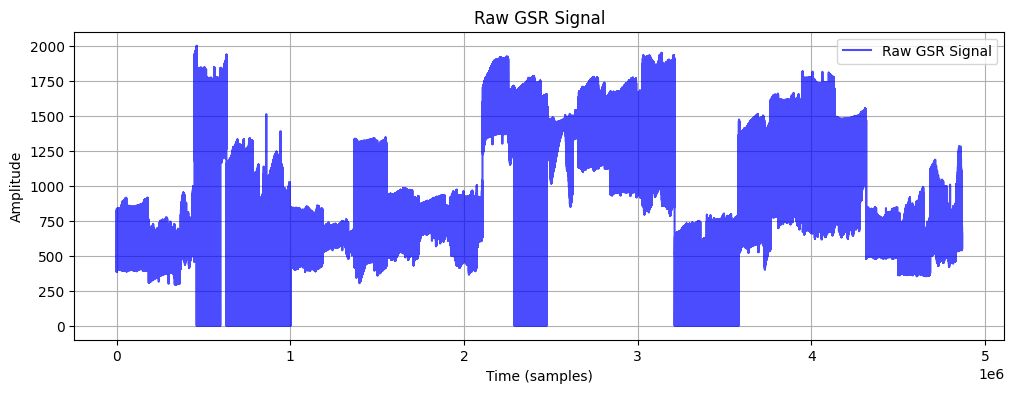

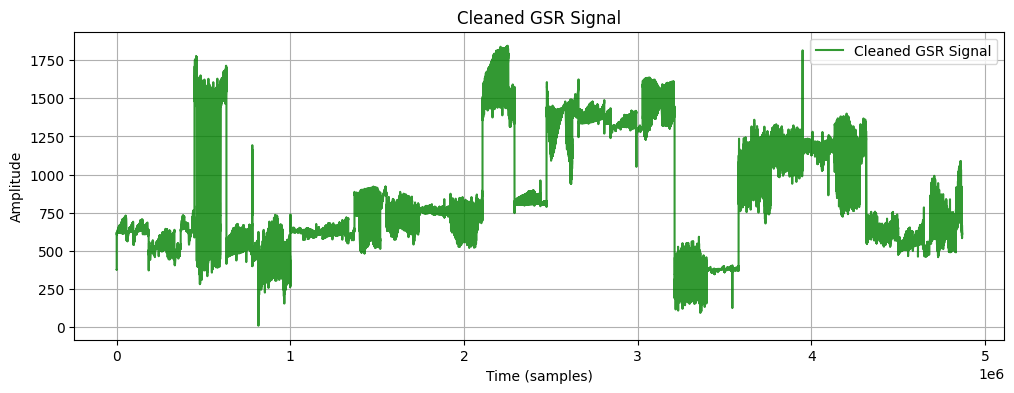

4610

In [21]:
# Plot raw GSR signal
plt.figure(figsize=(12, 4))
plt.plot(gsr_signal, label="Raw GSR Signal", color="blue", alpha=0.7)
plt.title("Raw GSR Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# Plot cleaned GSR signal
plt.figure(figsize=(12, 4))
plt.plot(filtered_gsr_signal["EDA_Clean"], label="Cleaned GSR Signal", color="green", alpha=0.8)
plt.title("Cleaned GSR Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

del filtered_gsr_signal
del gsr_signal
gc.collect()